# Tarea 2 — Física Computacional FIS205
## Universidad Técnica Federico Santa María

---

# Problema 1: Inteligencia artificial para problemas inversos

Oscilador armónico amortiguado:

$$m\ddot{x}(t) + \gamma \dot{x}(t) + k\, x(t) = 0$$

con $m=1$, $x(0)=1$, $\dot{x}(0)=0$.

## Instalar dependencias

In [15]:
!pip install scikit-learn -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Problema 1 b) — Generación del conjunto de datos ($N=3000$ señales)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import time

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

N       = 3000
Nt      = 1000
t_span  = (0, 10)
t_eval  = np.linspace(*t_span, Nt)
sigma   = 0.02

def resolver_oscilador(gamma, k, t_eval):
    def ode(t, y):
        return [y[1], -gamma * y[1] - k * y[0]]
    sol = solve_ivp(ode, (t_eval[0], t_eval[-1]), [1.0, 0.0],
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
    return sol.y[0]

gammas = np.random.uniform(0.05, 1.0, N)
ks     = np.random.uniform(1.0, 5.0, N)

X_data = np.zeros((N, Nt))
theta  = np.column_stack([gammas, ks])

t0 = time.time()
for i in range(N):
    X_data[i] = resolver_oscilador(gammas[i], ks[i], t_eval)
    if (i + 1) % 500 == 0:
        print(f'  Generadas {i+1}/{N} ({time.time()-t0:.1f}s)')

X_data += np.random.normal(0, sigma, X_data.shape)

print(f'Dataset listo en {time.time()-t0:.1f}s')
print(f'X_data.shape = {X_data.shape}, theta.shape = {theta.shape}')

  Generadas 500/3000 (8.8s)
  Generadas 1000/3000 (17.8s)
  Generadas 1500/3000 (26.5s)
  Generadas 2000/3000 (35.6s)
  Generadas 2500/3000 (45.1s)
  Generadas 3000/3000 (54.6s)
Dataset listo en 54.7s
X_data.shape = (3000, 1000), theta.shape = (3000, 2)


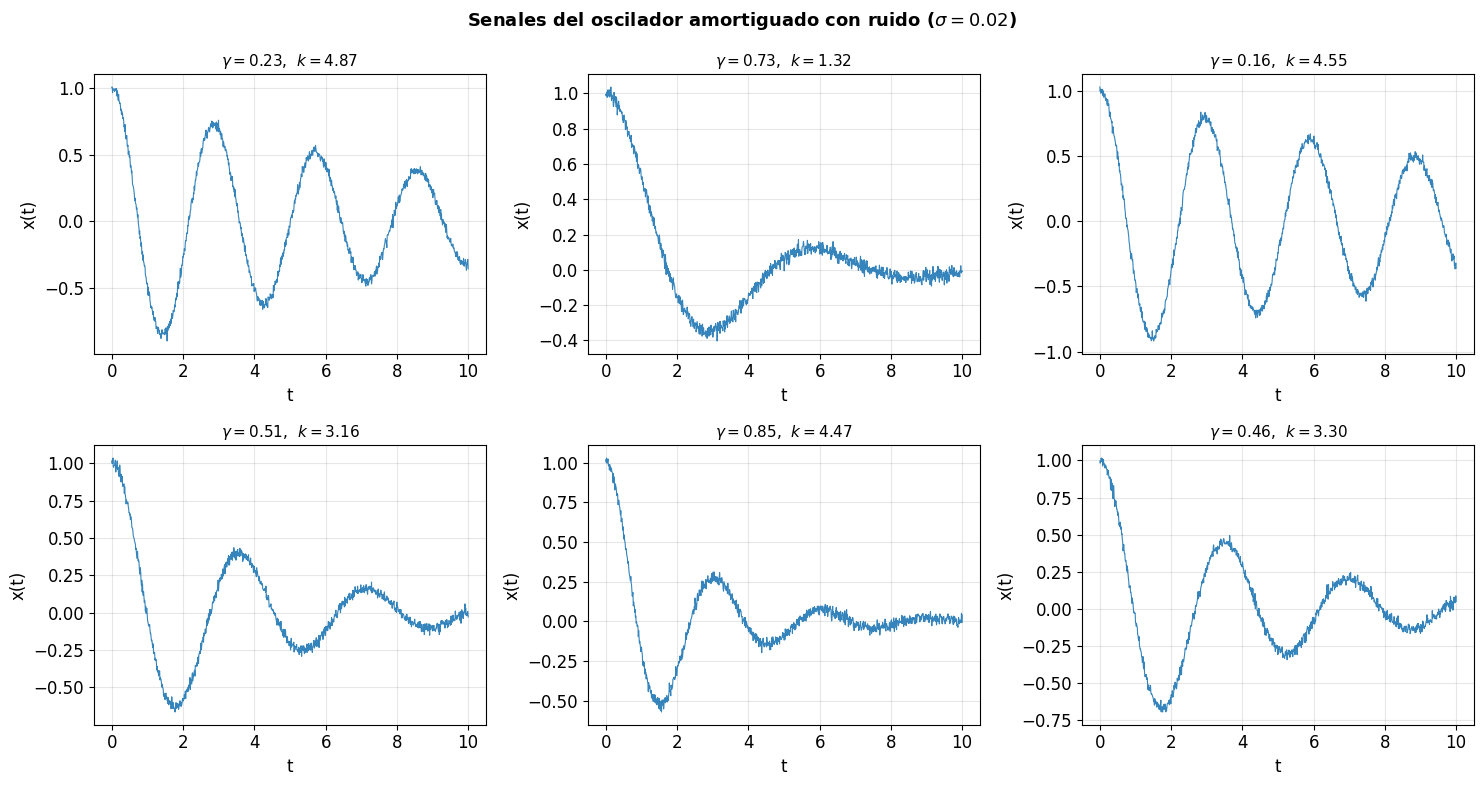

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

indices = np.random.choice(N, 6, replace=False)
for ax, idx in zip(axes, indices):
    ax.plot(t_eval, X_data[idx], lw=0.8, alpha=0.9)
    ax.set_title(r'$\gamma=$' + f'{gammas[idx]:.2f}' + r',  $k=$' + f'{ks[idx]:.2f}', fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('x(t)')

plt.suptitle(r'Senales del oscilador amortiguado con ruido ($\sigma=0.02$)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Problema 1 c) — Entrenamiento de modelos (RandomForest y MLP)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, theta, test_size=0.2, random_state=42
)
print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Validacion:    {X_test.shape[0]} muestras')

# --- Random Forest ---
print('\nEntrenando Random Forest...')
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f'  Listo en {time.time()-t0:.1f}s')

rmse_gamma_rf = np.sqrt(mean_squared_error(y_test[:, 0], y_pred_rf[:, 0]))
rmse_k_rf     = np.sqrt(mean_squared_error(y_test[:, 1], y_pred_rf[:, 1]))
print(f'  RMSE_gamma = {rmse_gamma_rf:.4f}')
print(f'  RMSE_k     = {rmse_k_rf:.4f}')

# --- MLP ---
print('\nEntrenando MLP...')
t0 = time.time()
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print(f'  Listo en {time.time()-t0:.1f}s')

rmse_gamma_mlp = np.sqrt(mean_squared_error(y_test[:, 0], y_pred_mlp[:, 0]))
rmse_k_mlp     = np.sqrt(mean_squared_error(y_test[:, 1], y_pred_mlp[:, 1]))
print(f'  RMSE_gamma = {rmse_gamma_mlp:.4f}')
print(f'  RMSE_k     = {rmse_k_mlp:.4f}')

Entrenamiento: 2400 muestras
Validacion:    600 muestras

Entrenando Random Forest...
  Listo en 46.9s
  RMSE_gamma = 0.0155
  RMSE_k     = 0.1638

Entrenando MLP...
  Listo en 4.3s
  RMSE_gamma = 0.0227
  RMSE_k     = 0.0255


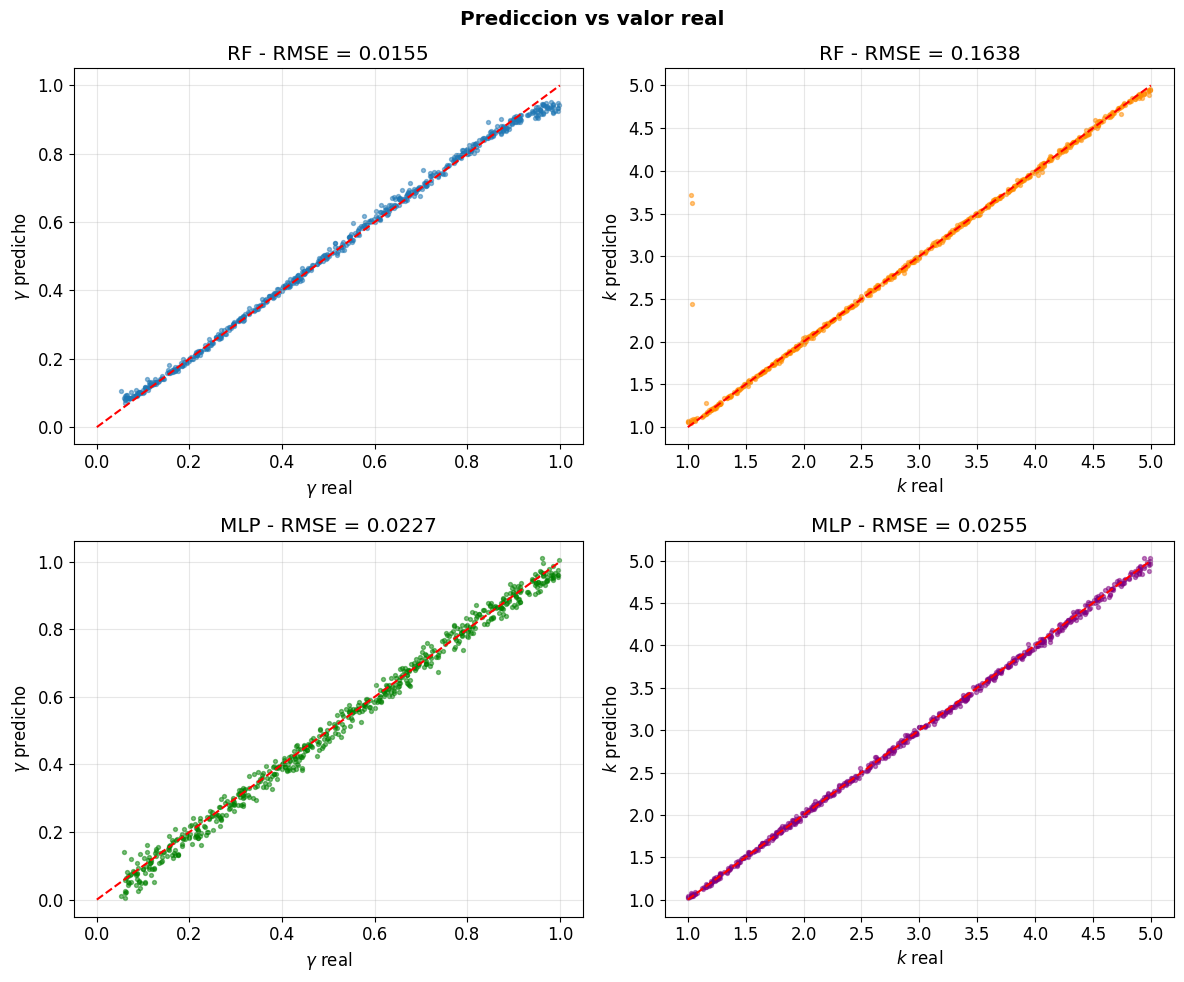

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test[:, 0], y_pred_rf[:, 0], s=8, alpha=0.5)
axes[0, 0].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[0, 0].set_xlabel(r'$\gamma$ real')
axes[0, 0].set_ylabel(r'$\gamma$ predicho')
axes[0, 0].set_title(f'RF - RMSE = {rmse_gamma_rf:.4f}')

axes[0, 1].scatter(y_test[:, 1], y_pred_rf[:, 1], s=8, alpha=0.5, color='darkorange')
axes[0, 1].plot([1, 5], [1, 5], 'r--', lw=1.5)
axes[0, 1].set_xlabel(r'$k$ real')
axes[0, 1].set_ylabel(r'$k$ predicho')
axes[0, 1].set_title(f'RF - RMSE = {rmse_k_rf:.4f}')

axes[1, 0].scatter(y_test[:, 0], y_pred_mlp[:, 0], s=8, alpha=0.5, color='green')
axes[1, 0].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[1, 0].set_xlabel(r'$\gamma$ real')
axes[1, 0].set_ylabel(r'$\gamma$ predicho')
axes[1, 0].set_title(f'MLP - RMSE = {rmse_gamma_mlp:.4f}')

axes[1, 1].scatter(y_test[:, 1], y_pred_mlp[:, 1], s=8, alpha=0.5, color='purple')
axes[1, 1].plot([1, 5], [1, 5], 'r--', lw=1.5)
axes[1, 1].set_xlabel(r'$k$ real')
axes[1, 1].set_ylabel(r'$k$ predicho')
axes[1, 1].set_title(f'MLP - RMSE = {rmse_k_mlp:.4f}')

plt.suptitle('Prediccion vs valor real', fontweight='bold')
plt.tight_layout()
plt.show()

## Problema 1 d) — Efecto del ruido sobre la inferencia

In [19]:
sigma_values = [0.0, 0.01, 0.02, 0.05, 0.10]

print('Pre-generando senales limpias...')
t0_total = time.time()
X_clean = np.zeros((N, Nt))
for i in range(N):
    X_clean[i] = resolver_oscilador(gammas[i], ks[i], t_eval)
    if (i + 1) % 1000 == 0:
        print(f'  {i+1}/{N}...')
print(f'  Listo en {time.time()-t0_total:.1f}s')

results = {
    'sigma': [],
    'rf_rmse_gamma': [], 'rf_rmse_k': [],
    'rf_rmse_gamma_train': [], 'rf_rmse_k_train': [],
    'mlp_rmse_gamma': [], 'mlp_rmse_k': [],
    'mlp_rmse_gamma_train': [], 'mlp_rmse_k_train': [],
}

for sig in sigma_values:
    print(f'\n--- sigma = {sig} ---')
    t0 = time.time()

    if sig > 0:
        X_sig = X_clean + np.random.normal(0, sig, X_clean.shape)
    else:
        X_sig = X_clean.copy()

    Xtr, Xte, ytr, yte = train_test_split(X_sig, theta, test_size=0.2, random_state=42)

    rf_s = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    rf_s.fit(Xtr, ytr)
    yp_rf_test  = rf_s.predict(Xte)
    yp_rf_train = rf_s.predict(Xtr)

    mlp_s = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                         solver='adam', max_iter=500, random_state=42,
                         early_stopping=True, validation_fraction=0.1)
    mlp_s.fit(Xtr, ytr)
    yp_mlp_test  = mlp_s.predict(Xte)
    yp_mlp_train = mlp_s.predict(Xtr)

    rg_rf  = np.sqrt(mean_squared_error(yte[:, 0], yp_rf_test[:, 0]))
    rk_rf  = np.sqrt(mean_squared_error(yte[:, 1], yp_rf_test[:, 1]))
    rg_mlp = np.sqrt(mean_squared_error(yte[:, 0], yp_mlp_test[:, 0]))
    rk_mlp = np.sqrt(mean_squared_error(yte[:, 1], yp_mlp_test[:, 1]))

    rg_rf_tr  = np.sqrt(mean_squared_error(ytr[:, 0], yp_rf_train[:, 0]))
    rk_rf_tr  = np.sqrt(mean_squared_error(ytr[:, 1], yp_rf_train[:, 1]))
    rg_mlp_tr = np.sqrt(mean_squared_error(ytr[:, 0], yp_mlp_train[:, 0]))
    rk_mlp_tr = np.sqrt(mean_squared_error(ytr[:, 1], yp_mlp_train[:, 1]))

    results['sigma'].append(sig)
    results['rf_rmse_gamma'].append(rg_rf);  results['rf_rmse_k'].append(rk_rf)
    results['rf_rmse_gamma_train'].append(rg_rf_tr);  results['rf_rmse_k_train'].append(rk_rf_tr)
    results['mlp_rmse_gamma'].append(rg_mlp); results['mlp_rmse_k'].append(rk_mlp)
    results['mlp_rmse_gamma_train'].append(rg_mlp_tr); results['mlp_rmse_k_train'].append(rk_mlp_tr)

    print(f'  RF  -> RMSE_g={rg_rf:.4f}  RMSE_k={rk_rf:.4f}')
    print(f'  MLP -> RMSE_g={rg_mlp:.4f}  RMSE_k={rk_mlp:.4f}')
    print(f'  ({time.time()-t0:.1f}s)')

Pre-generando senales limpias...
  1000/3000...
  2000/3000...
  3000/3000...
  Listo en 55.8s

--- sigma = 0.0 ---
  RF  -> RMSE_g=0.0092  RMSE_k=0.0102
  MLP -> RMSE_g=0.0137  RMSE_k=0.0156
  (58.2s)

--- sigma = 0.01 ---
  RF  -> RMSE_g=0.0120  RMSE_k=0.2098
  MLP -> RMSE_g=0.0146  RMSE_k=0.0212
  (61.2s)

--- sigma = 0.02 ---
  RF  -> RMSE_g=0.0154  RMSE_k=0.1598
  MLP -> RMSE_g=0.0197  RMSE_k=0.0254
  (61.4s)

--- sigma = 0.05 ---
  RF  -> RMSE_g=0.0310  RMSE_k=0.0917
  MLP -> RMSE_g=0.0379  RMSE_k=0.0475
  (58.0s)

--- sigma = 0.1 ---
  RF  -> RMSE_g=0.0588  RMSE_k=0.1450
  MLP -> RMSE_g=0.0521  RMSE_k=0.0843
  (64.5s)


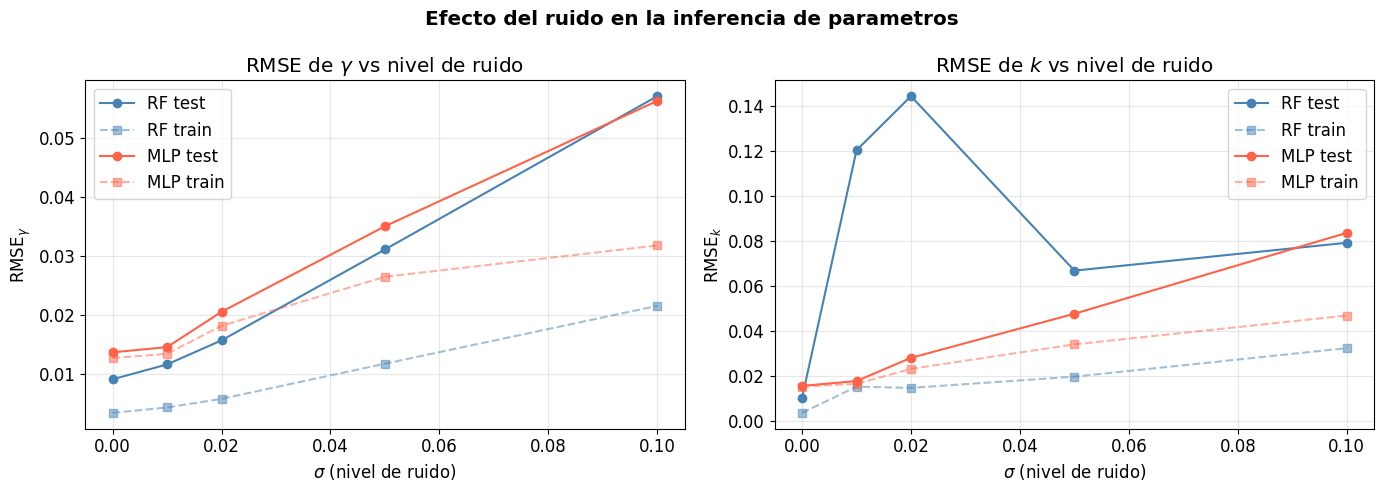

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sigs = results['sigma']

axes[0].plot(sigs, results['rf_rmse_gamma'],       'o-',  color='steelblue', label='RF test')
axes[0].plot(sigs, results['rf_rmse_gamma_train'],  's--', color='steelblue', alpha=0.5, label='RF train')
axes[0].plot(sigs, results['mlp_rmse_gamma'],       'o-',  color='tomato', label='MLP test')
axes[0].plot(sigs, results['mlp_rmse_gamma_train'], 's--', color='tomato', alpha=0.5, label='MLP train')
axes[0].set_xlabel(r'$\sigma$ (nivel de ruido)')
axes[0].set_ylabel(r'RMSE$_\gamma$')
axes[0].set_title(r'RMSE de $\gamma$ vs nivel de ruido')
axes[0].legend()

axes[1].plot(sigs, results['rf_rmse_k'],       'o-',  color='steelblue', label='RF test')
axes[1].plot(sigs, results['rf_rmse_k_train'],  's--', color='steelblue', alpha=0.5, label='RF train')
axes[1].plot(sigs, results['mlp_rmse_k'],       'o-',  color='tomato', label='MLP test')
axes[1].plot(sigs, results['mlp_rmse_k_train'], 's--', color='tomato', alpha=0.5, label='MLP train')
axes[1].set_xlabel(r'$\sigma$ (nivel de ruido)')
axes[1].set_ylabel(r'RMSE$_k$')
axes[1].set_title(r'RMSE de $k$ vs nivel de ruido')
axes[1].legend()

plt.suptitle('Efecto del ruido en la inferencia de parametros', fontweight='bold')
plt.tight_layout()
plt.show()

---
# Problema 2: Terapia con protones

Simulación Monte Carlo del transporte de protones en agua y caracterización del pico de Bragg.

## Problema 2 b) — Bethe-Bloch y rango CSDA

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time

def bethe_bloch_proton_agua(E_MeV):
    if E_MeV < 0.1:
        return 0.0
    mp   = 938.272
    me   = 0.511
    K    = 0.307075
    Z_A  = 0.5551
    rho  = 1.0
    I    = 75e-6
    gamma_l = 1.0 + E_MeV / mp
    beta2   = 1.0 - 1.0 / gamma_l**2
    Tmax = (2 * me * beta2 * gamma_l**2) / (1 + 2 * gamma_l * me / mp + (me / mp)**2)
    arg  = 2 * me * beta2 * gamma_l**2 * Tmax / I**2
    if arg <= 1 or beta2 <= 0:
        return 0.0
    return max(K * rho * Z_A / beta2 * (0.5 * np.log(arg) - beta2), 0.0)


def bethe_bloch_vec(E_arr):
    E_arr = np.asarray(E_arr, dtype=float)
    result = np.zeros_like(E_arr)
    mask = E_arr >= 0.1
    mp = 938.272; me = 0.511; K = 0.307075
    Z_A = 0.5551; rho = 1.0; I = 75e-6
    E = E_arr[mask]
    gamma_l = 1.0 + E / mp
    beta2 = 1.0 - 1.0 / gamma_l**2
    Tmax  = (2 * me * beta2 * gamma_l**2) / (1 + 2 * gamma_l * me / mp + (me / mp)**2)
    arg   = 2 * me * beta2 * gamma_l**2 * Tmax / I**2
    valid = (arg > 1) & (beta2 > 0)
    vals  = np.zeros_like(E)
    vals[valid] = K * rho * Z_A / beta2[valid] * (0.5 * np.log(arg[valid]) - beta2[valid])
    vals = np.maximum(vals, 0.0)
    result[mask] = vals
    return result


def rango_CSDA(E0_MeV, dE=0.1):
    R = 0.0
    E = E0_MeV
    while E > 0.5:
        dEdx = bethe_bloch_proton_agua(E)
        if dEdx <= 0:
            break
        step = min(dE, E - 0.5)
        R += step / dEdx
        E -= step
    return R


energias_test = [50, 150, 250]

print('Rango CSDA calculado con Bethe-Bloch:')
print(f'{"E0 (MeV)":>10}  {"R_CSDA (cm)":>12}')
print('-' * 25)
for E0 in energias_test:
    R = rango_CSDA(E0)
    print(f'{E0:>10}  {R:>12.2f}')

print('\nValores PSTAR (NIST):')
print('  50 MeV  -> R aprox 2.18 cm')
print('  150 MeV -> R aprox 15.79 cm')
print('  250 MeV -> R aprox 37.67 cm')

Rango CSDA calculado con Bethe-Bloch:
  E0 (MeV)   R_CSDA (cm)
-------------------------
        50          2.23
       150         15.78
       250         37.94

Valores PSTAR (NIST):
  50 MeV  -> R aprox 2.18 cm
  150 MeV -> R aprox 15.79 cm
  250 MeV -> R aprox 37.67 cm


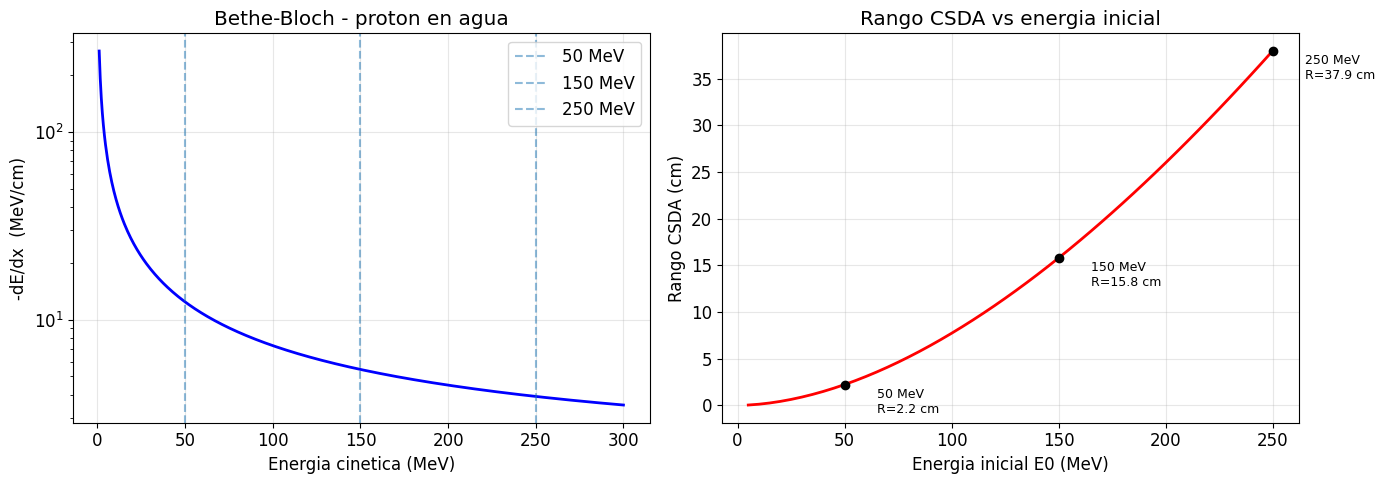

In [9]:
E_range  = np.linspace(1, 300, 500)
dEdx_arr = np.array([bethe_bloch_proton_agua(E) for E in E_range])

E_rango = np.linspace(5, 250, 50)
rangos  = np.array([rango_CSDA(E) for E in E_rango])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(E_range, dEdx_arr, 'b-', lw=2)
axes[0].set_xlabel('Energia cinetica (MeV)')
axes[0].set_ylabel('-dE/dx  (MeV/cm)')
axes[0].set_title('Bethe-Bloch - proton en agua')
for E0 in energias_test:
    axes[0].axvline(E0, ls='--', alpha=0.5, label=f'{E0} MeV')
axes[0].legend()

axes[1].plot(E_rango, rangos, 'r-', lw=2)
axes[1].set_xlabel('Energia inicial E0 (MeV)')
axes[1].set_ylabel('Rango CSDA (cm)')
axes[1].set_title('Rango CSDA vs energia inicial')
for E0 in energias_test:
    R = rango_CSDA(E0)
    axes[1].plot(E0, R, 'ko', ms=6)
    axes[1].annotate(f'{E0} MeV\nR={R:.1f} cm', xy=(E0, R),
                     xytext=(E0+15, R-3), fontsize=9)

plt.tight_layout()
plt.show()

## Problema 2 c) — Simulación de $10^4$ protones sin straggling ($E_0 = 150$ MeV)

In [10]:
E0       = 150.0
N_prot   = 10000
dx_cm    = 0.01

R_csda   = rango_CSDA(E0)
print(f'R_CSDA(150 MeV) = {R_csda:.2f} cm')

x_max  = R_csda * 1.15
n_bins = int(x_max / dx_cm) + 1
dosis_sin = np.zeros(n_bins)

E = E0
for i in range(n_bins):
    dEdx = bethe_bloch_proton_agua(E)
    if dEdx <= 0 or E < 0.1:
        break
    dE = min(dEdx * dx_cm, E)
    dosis_sin[i] = dE * N_prot
    E -= dE

x_centros = (np.arange(n_bins) + 0.5) * dx_cm
dosis_sin_norm = dosis_sin / dosis_sin.max()

idx_peak = np.argmax(dosis_sin)
x_peak   = x_centros[idx_peak]

print(f'Posicion del pico de Bragg: {x_peak:.2f} cm')
print(f'R_CSDA:                     {R_csda:.2f} cm')

R_CSDA(150 MeV) = 15.78 cm
Posicion del pico de Bragg: 15.79 cm
R_CSDA:                     15.78 cm


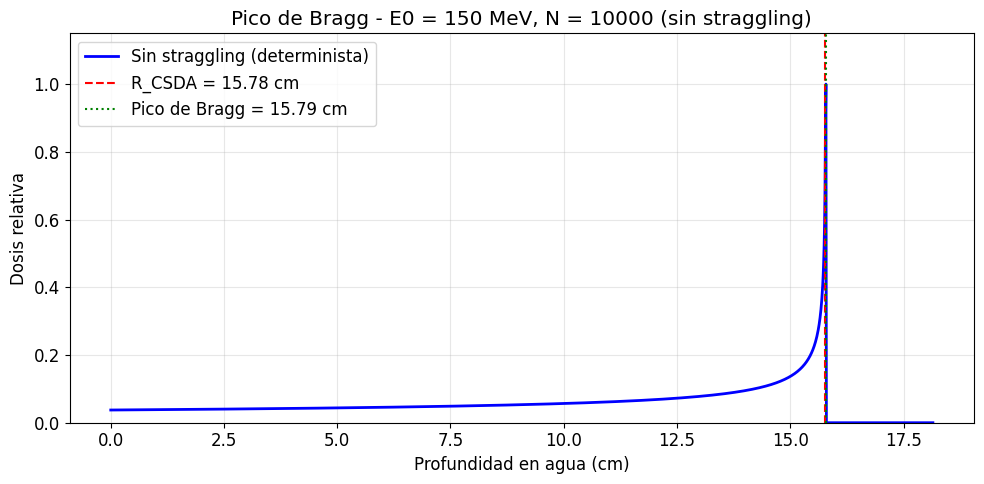

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_centros, dosis_sin_norm, 'b-', lw=2, label='Sin straggling (determinista)')
ax.axvline(R_csda, color='red', ls='--', lw=1.5,
           label=f'R_CSDA = {R_csda:.2f} cm')
ax.axvline(x_peak, color='green', ls=':', lw=1.5,
           label=f'Pico de Bragg = {x_peak:.2f} cm')
ax.set_xlabel('Profundidad en agua (cm)')
ax.set_ylabel('Dosis relativa')
ax.set_title(f'Pico de Bragg - E0 = 150 MeV, N = {N_prot} (sin straggling)')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Problema 2 d) — Simulación con energy straggling

In [12]:
def sigma_straggling_vec(E_arr, dx_cm):
    E_arr  = np.asarray(E_arr, dtype=float)
    result = np.zeros_like(E_arr)
    mask   = E_arr >= 0.1
    mp = 938.272; me = 0.511
    re = 2.8179e-13
    Ne = 3.343e23
    E     = E_arr[mask]
    gamma_l = 1.0 + E / mp
    beta2 = 1.0 - 1.0 / gamma_l**2
    valid = beta2 > 0
    sigma2 = np.zeros_like(E)
    sigma2[valid] = 4 * np.pi * re**2 * me**2 * Ne / beta2[valid] * dx_cm
    result[mask]  = np.sqrt(np.maximum(sigma2, 0.0))
    return result


np.random.seed(42)

print(f'Simulando {N_prot} protones con straggling...')
t0 = time.time()

E_all = np.full(N_prot, E0)
alive = np.ones(N_prot, dtype=bool)
rangos_proton = np.zeros(N_prot)

n_bins_strag = int(x_max / dx_cm) + 1
dosis_con = np.zeros(n_bins_strag)

step = 0
max_steps = n_bins_strag + 500

while np.any(alive) and step < max_steps:
    idx_alive = np.where(alive)[0]
    E_live = E_all[idx_alive]

    dEdx     = bethe_bloch_vec(E_live)
    dE_medio = dEdx * dx_cm

    sig_E = sigma_straggling_vec(E_live, dx_cm)
    fluct = np.random.normal(0, 1, len(idx_alive)) * sig_E
    dE    = np.clip(dE_medio + fluct, 0, E_live)

    if step < len(dosis_con):
        dosis_con[step] += np.sum(dE)

    E_all[idx_alive] -= dE

    stopped = E_all[idx_alive] < 0.1
    newly_stopped = idx_alive[stopped]
    rangos_proton[newly_stopped] = (step + 1) * dx_cm
    alive[newly_stopped] = False

    step += 1
    if step % 500 == 0:
        print(f'  Paso {step}, protones vivos: {np.sum(alive)}/{N_prot}')

rangos_proton[alive] = step * dx_cm

elapsed = time.time() - t0
print(f'\nSimulacion completa en {elapsed:.1f}s')

x_centros_strag = (np.arange(n_bins_strag) + 0.5) * dx_cm
dosis_con_norm  = dosis_con / dosis_con.max()

sigma_R     = np.std(rangos_proton)
rango_medio = np.mean(rangos_proton)

print(f'Rango medio:      {rango_medio:.2f} cm')
print(f'sigma_R:          {sigma_R:.4f} cm')
print(f'R_CSDA:           {R_csda:.2f} cm')

Simulando 10000 protones con straggling...
  Paso 500, protones vivos: 10000/10000
  Paso 1000, protones vivos: 10000/10000
  Paso 1500, protones vivos: 2745/10000

Simulacion completa en 1.6s
Rango medio:      14.83 cm
sigma_R:          0.2882 cm
R_CSDA:           15.78 cm


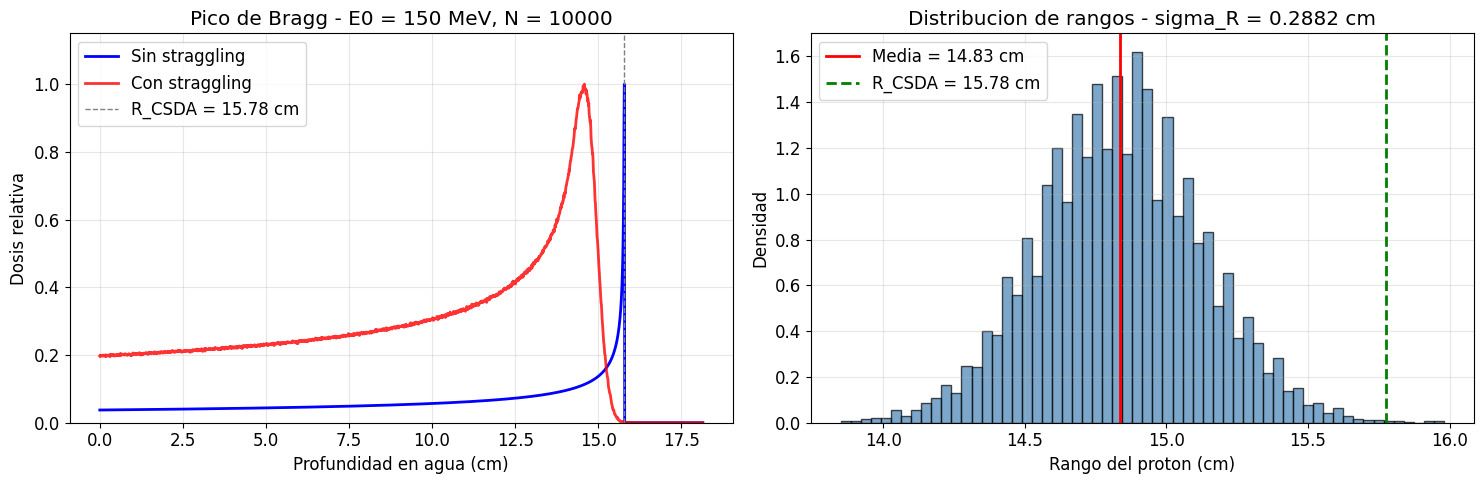

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(x_centros, dosis_sin_norm, 'b-', lw=2, label='Sin straggling')
axes[0].plot(x_centros_strag, dosis_con_norm, 'r-', lw=2, alpha=0.8, label='Con straggling')
axes[0].axvline(R_csda, color='gray', ls='--', lw=1,
                label=f'R_CSDA = {R_csda:.2f} cm')
axes[0].set_xlabel('Profundidad en agua (cm)')
axes[0].set_ylabel('Dosis relativa')
axes[0].set_title(f'Pico de Bragg - E0 = {E0:.0f} MeV, N = {N_prot}')
axes[0].legend()
axes[0].set_ylim(0, 1.15)

axes[1].hist(rangos_proton, bins=60, color='steelblue', alpha=0.7,
             edgecolor='black', density=True)
axes[1].axvline(rango_medio, color='red', ls='-', lw=2,
                label=f'Media = {rango_medio:.2f} cm')
axes[1].axvline(R_csda, color='green', ls='--', lw=2,
                label=f'R_CSDA = {R_csda:.2f} cm')
axes[1].set_xlabel('Rango del proton (cm)')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Distribucion de rangos - sigma_R = {sigma_R:.4f} cm')
axes[1].legend()

plt.tight_layout()
plt.show()